In [33]:
library(ggplot2)
library(scales)

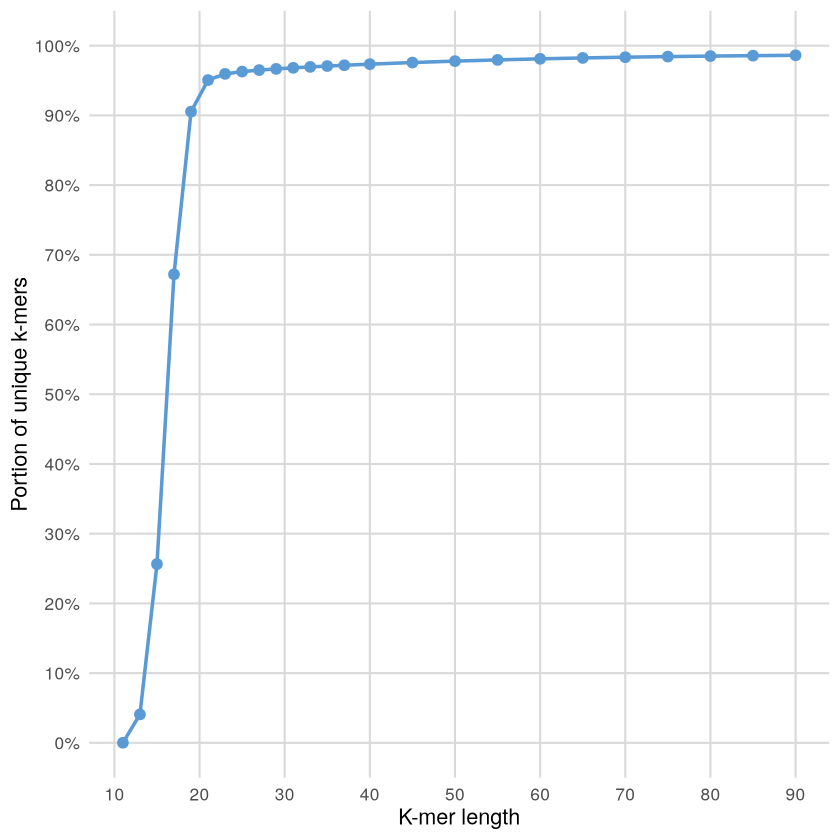

In [34]:
data = read.table("/srv/home/mlef0011/VDARK/output/count_ref_genome/summary_kmer_counts.tsv", header=T)[,1:2]
data$specific_kmers = sapply(data$K, function(k){
    file = paste0("/srv/home/mlef0011/VDARK/output/count_ref_genome/ref_genome_k",k,"_kmc.histo")
    if (file.exists(file)){
        return(read.table(file, nrows=1)[[2]])
    } else {
        return(NA)
    }
})
data$prop_unique = data$specific_kmers/data$n_unique_kmers
data = data[!is.na(data$prop_unique),]


ggplot(data, aes(x = K, y = prop_unique)) +
    geom_line(color = "#5B9BD5", linewidth = 1) +
    geom_point(color = "#5B9BD5", size = 2.5) +
    scale_x_continuous(breaks = seq(0, max(data$K) + 10, by = 10)) +
    scale_y_continuous(labels = percent_format(accuracy = 1),
                       limits = c(0, 1), breaks = seq(0, 1, 0.1)) +
    labs(title = NULL,
         x = "K-mer length",
         y = "Portion of unique k-mers") +
    theme_minimal(base_size = 13) +
    theme(
        plot.title      = element_text(hjust = 0, size = 15, margin = margin(b = 15)),
        panel.grid.minor = element_blank(),
        panel.grid.major = element_line(color = "grey85")
    )

In [19]:
k = 90
file = paste0("/srv/home/mlef0011/VDARK/output/count_ref_genome/ref_genome_k",k,"_kmc.histo")
histo = read.table(file)
k_u = histo[1,2]
n_t = data[data$K == k,3]
(n_t - k_u)/n_t*100

[1] 4.196067

In [3]:
data = read.table("/srv/home/mlef0011/VDARK/output/count_ref_genome/summary_kmer_counts.tsv", header=T)
data

K,n_unique_kmers,n_total_kmers
<int>,<dbl>,<dbl>
11,2097100,2900272556
13,32384893,2900259493
15,334292769,2900246447
17,1394147479,2900233411
19,2073931611,2900220385
21,2258530531,2900207370
23,2334127713,2900194374
25,2387424159,2900181389
27,2432056123,2900168417
